# Git

Git is a distributed version control system that allows multiple developers to work on a project simultaneously.
It helps track changes to files and coordinate work among team members.
Git is widely used in software development and is the backbone of platforms like GitHub or GitLab.

# Key Concepts

- **Repository (Repo)**: A repository is a storage space where your project lives. It can be local (on your computer) or remote (on a server).

- **Commit**: A commit is a snapshot of your repository at a specific point in time. It includes a message describing the changes made.

- **Branch**: A branch is a separate line of development within a repository. It allows you to work on different features or experiments without affecting the main codebase.

- **Merge**: A merge is the process of combining changes from different branches into a single branch.

- **Pull Request (PR)**: A pull request is a way to propose changes to a repository. It allows team members to review and discuss the changes before merging them into the main branch.

# Repositories

When working alone, you typically have two repositories:

- Local repository on your computer: this is where you make changes and commit them.

- Remote repository on a server (like GitHub): this is where your work is backed up and shared with others.

When working in a team, a simple workflow is that each member has their own local repository, and they all push their changes to the shared remote repository.

A robust workflow on large projects is the [fork-and-pull model](https://en.wikipedia.org/wiki/Fork_and_pull_model):

- There is a central repository located on a platform like GitHub. Just a limited number of people have write access to this repository.

- Each contributor forks the main repository, creating a copy of it under their own account. The forked repository is also located on the same remote platform.

- Contributors also clone their forked repository to their local machine, creating a local repository where they can make changes.

- After making changes and committing them to their local repository, contributors push their commits to their forked repository on the remote platform.

- Finally, contributors create a pull request from their forked repository to the main repository, proposing their changes for review and potential merging.

# Quick Start Guide

- Create a new repository on GitHub by clicking the plus sign in the top right corner and selecting "New repository".

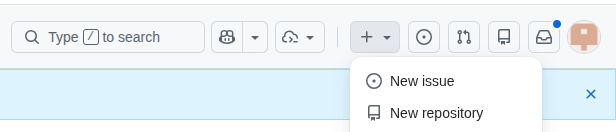

- Fill in the repository name and description, choose whether it should be public or private, etc.

- Copy the URL of the repository by  clicking the "Code" button and copying the URL under "HTTPS".

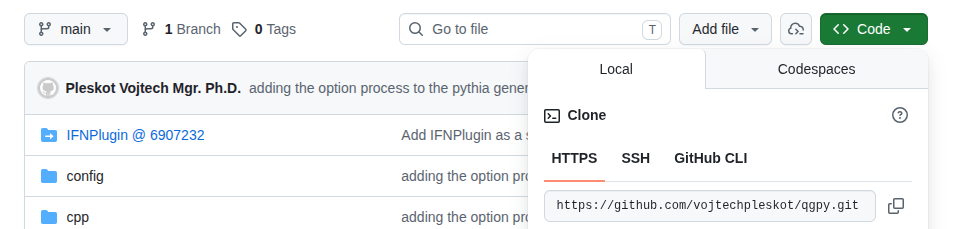

- Clone the repository to your local machine using the command line:
    ```bash
    git clone <repository-url>
    ```

- Change into the repository directory:
    ```bash
    cd <repository-name>
    ```

- Create some file and make changes to it.
    ```bash
    echo "Hello, Git!" > hello.txt
    ```

- Check the status of your repository to see which files have been changed:
    ```bash
    git status
    ```
    As you can see, the `hello.txt` file is untracked (it is not yet part of the repository). To add it to the repository, use the `git add` command:
    ```bash
    git add hello.txt
    ```
    This stages the file for commit. Now, if you check the status again, you will see that `hello.txt` is staged for commit.

- Now, you can commit the changes to the repository with a message describing the changes:
    ```bash
    git commit -m "Add hello.txt"
    ```

- Check the commit history to see your commit:
    ```bash
    git log
    ```

- Push the changes to the remote repository on GitHub, so that it is synced with your local repository:
    ```bash
    git push origin main
    ```
    This command pushes your commits to the `main` branch of the remote repository.
    Note that simple `git push` will work when the current local branch is tracking the remote branch.
    To check if the current branch is tracking a remote branch, you can use:
    ```bash
    git branch -vv
    ```
    To set up tracking, you can use:
    ```bash
    git push -u origin main
    ```

# Pushing to GitHub with HTTPS

When pushing with HTTPS, GitHub will ask for your credentials.
Use your GitHub username.
Unfortunately, GitHub no longer allows you to use your password for authentication.
Instead, you can generate and use a personal access token (PAT):

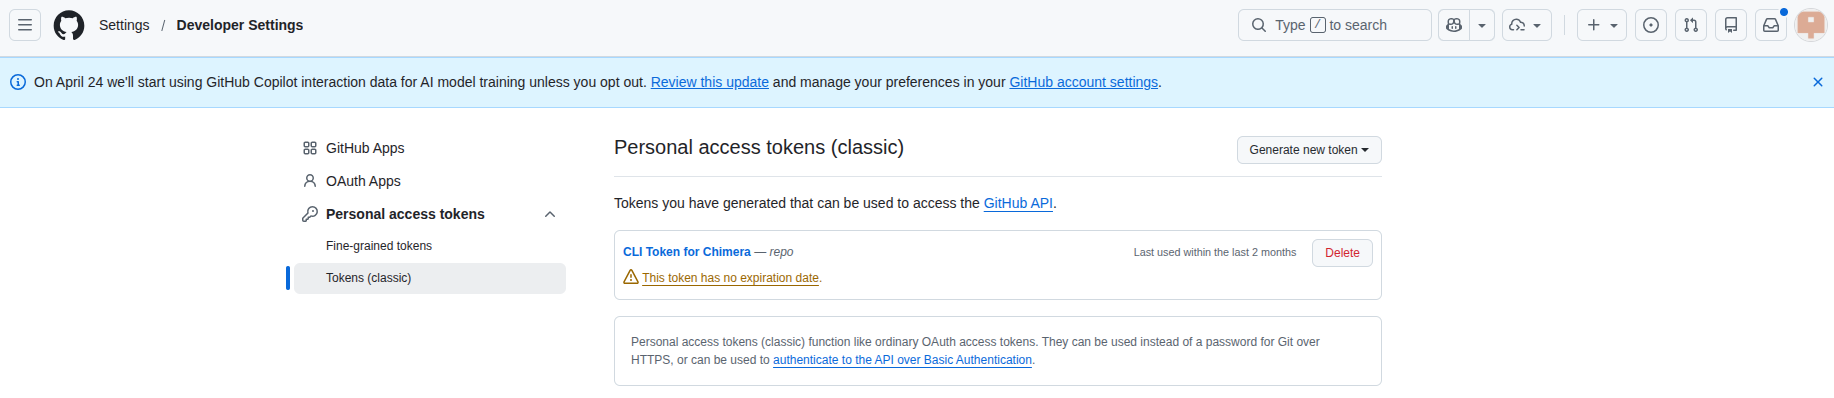

- Log in to GitHub, then click your profile icon and go to Settings.

- On the left sidebar, scroll to the bottom and click Developer settings.

- Click Personal access tokens > Tokens (classic).

- Select Generate new token (classic).

- Give it a name, and an expiration date (you can also choose "No expiration").

- Scopes: Select the repo checkbox (this allows pushing/pulling).

- Generate: Click the button at the bottom.

- IMPORTANT: Copy the token immediately. Once you leave the page, you will never see it again. Paste it e.g. into a temporary text file.


# Pushing to GitHub with SSH

When pushing with SSH, you need to use a different URL for the repository, which looks like this:
```bash
git@github.com:username/repository.git
```
e.g.
```bash
git@github.com:vojtechpleskot/testing-git.git
```
To use SSH for pushing to GitHub, you need to set up an SSH key pair on your local machine and add the public key to your GitHub account.
If you did it when inspecting the `14_chimera_cluster.ipynb` notebook, you can reuse the same key pair for GitHub as well.

- Go to your GitHub account settings, then click "SSH and GPG keys" in the left sidebar.

- Click "New SSH key", give it a title (e.g. "My Laptop").

- Paste the whole content of the file `$HOME\.ssh\id_ed25519.pub` of your public key into the "Key" field.


# Branches

- Branches are something like "lightweight copies" of the project.

- They help isolate development changes and experiments from the main codebase.

- There can be any number of branches in a repository, and they can be created, deleted, and merged as needed.

Common types of branches in a repository:

- Main branch (often called `main` or `master`): This is the primary branch where the stable code resides.

- Development branches (often called `dev` or `develop`): These are branches where active development happens. They are used to isolate changes before merging them into the main branch.

- Feature branches: These are temporary branches created for developing specific features. Once the feature is complete, it is merged back into the development branch.

Working with branches:

- Create a new branch from the current branch:
    ```bash
    git branch <the-new-branch-name>
    ```

- Switch to a branch:
    ```bash
    git switch <the-new-branch-name>
    ```
- Create and switch to a new branch in one command:
    ```bash
    git switch -c <the-new-branch-name>
    ```

- Push the branch to the remote repository so that others can see them and collaborate on them:
    ```bash
    git push -u origin <the-new-branch-name>
    ```
    The `-u` flag makes the branch track the remote branch, so that future pushes can be done with just `git push`.

- When you are done with the development on a branch, you can merge it back into the main branch:
    ```bash
    git switch main
    git merge <the-new-branch-name>
    ```

- When a branch is no longer needed, it can be deleted:
    ```bash
    git branch -d <the-new-branch-name>
    ```
    To delete a branch that has not been merged, use the `-D` flag instead of `-d`.

# More on branches

- One can create a new branch from a different branch than the current one or even from a specific commit:
    ```bash
    git switch -c <the-new-branch-name> <the-base-branch-name>
    git switch -c <the-new-branch-name> <the-base-commit-hash>
    ```
    The commit hash can be found in the commit history (`git log`). It is a long string of characters that uniquely identifies a commit, for example: `a2d2326f0cc6ed69d543b3550c1304636184e9dc`.

- When working in a team, pull the latest changes from the remote repository often (e.g. before starting work on a new feature). This helps avoid conflicts and ensures that you are working with the most up-to-date code:
    ```bash
    git fetch origin      # Just fetch the latest changes, first.
    git merge origin/main # This merges the branch `origin/main` into your current branch.
    ```

# Conflict resolution

- When multiple people are working on the same codebase, conflicts can arise when two or more people make changes to the same lines of code.

- When merging a branch, Git will automatically try to merge the changes. If it cannot do so cleanly, it will mark the conflicting files and ask you to resolve the conflicts manually.

- Git marks the conflicting sections in the file with special markers. You will see something like this in the file:
    ```plaintext
    <<<<<<< HEAD
    // Your changes
    =======
    // Changes from the branch you are merging
    >>>>>>> branch-name
    ```
    You need to edit the file to resolve the conflict by choosing which changes to keep, or by combining them in a way that makes sense.

- VS Code provides a user-friendly interface for resolving conflicts. When you open a file with conflicts in VS Code, it will show you the conflicting sections and provide options to accept changes from either side or to manually edit the file.

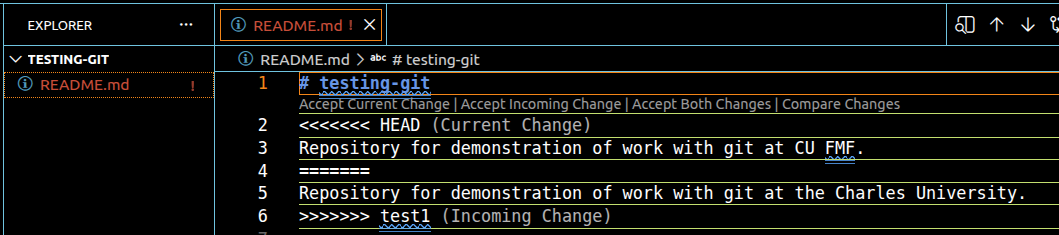
    
    
- After resolving the conflicts, you need to stage the resolved file and commit the changes to complete the merge process.
    ```bash
    git add README.md
    git commit -m "Resolve merge conflict in README.md"
    ```

# Inspecting differences

- To see the changes you have made to a file before committing, you can use the `git diff` command:
    ```bash
    git diff README.md
    ```
    This will show you the differences between the current state of the file and the last committed version.

- To see the changes that have been staged for commit, you can use:
    ```bash
    git diff --cached README.md
    ```

- To see changes between two branches, you can use:
    ```bash
    git diff main test1 -- README.md
    ```
    The order of the branches matters. The above command will show you the changes that would be applied to `main` if you were to merge `test1` into it.

- To see changes between two commits, you can use:
    ```bash
    git diff <commit-hash-1> <commit-hash-2> -- README.md
    ```

- To see differing commits between two branches, use:
    ```bash
    git log main...test1
    ```

- To see the commits that are in `test1` but not in `main`, use:
    ```bash
    git log main..test1
    ```


# Reverting changes

- If you want to undo changes that you have made to a file before committing, you can use the `git restore` command:
    ```bash
    git restore README.md
    ```
    This will discard any changes you have made to `README.md` and restore it to the last committed state.

- If you have already staged the changes for commit, you can unstage them using:
    ```bash
    git restore --staged README.md
    ```

- If you want to undo a commit that has already been made, you can use the `git revert` command:
    ```bash
    git revert <commit-hash>
    ```
    This will create a new commit that undoes the changes made in the specified commit. It is a safe way to undo changes because it does not alter the commit history.


# .gitignore file

- The `.gitignore` file is used to specify files and directories that Git should ignore when tracking changes in the repository.

- This is useful for excluding temporary files, build artifacts, or any other files that should not be committed to the repository.

- Example `.gitignore` content:
    ```plaintext
    # Ignore all .pyc files
    *.pyc

    # Ignore the __pycache__ directory
    __pycache__/
    ```

# README.md file

- The `README.md` file is a markdown file that provides an introduction and documentation for the project. It is often the first thing that people see when they visit a repository on GitHub.

- Markdown is a lightweight markup language that allows you to format text using simple syntax. It is commonly used for writing documentation, README files, and other text-based content in repositories.

    - Text cells in Jupyter notebooks support markdown.

# Markdown syntax

- Headers: Use `#` for headers. The number of `#` symbols indicates the level of the header (e.g., `#` for H1, `##` for H2, etc.).
    ```markdown
    # This is a header
    ## This is a subheader
    ```

- Lists: Use `-` or `*` for unordered lists, and numbers for ordered lists.
    ```markdown
    - Item 1
    - Item 2

    1. First item
    2. Second item
    ```

- Links: Use `[link text](URL)` to create a hyperlink.
    ```markdown
    [GitHub](https://github.com)
    ```

- Images: Use `![alt text](image URL)` to embed an image.
    ```markdown
    ![GitHub Logo](https://github.githubassets.com/images/modules/logos_page/GitHub-Mark.png)
    ```

    - The image URL can also be a relative path to an image file in the repository.

- Code blocks: Use triple backticks (```) to create a code block. You can also specify the language for syntax highlighting.
    ```text
    ```markdown
    ```python
    ```bash
    ```text
    ```
    Close it with triple backticks (```).

- Tables: Use pipes (`|`) and dashes (`-`) to create tables.
    ```markdown
    | Header 1 | Header 2 |
    |----------|----------|
    | Cell 1   | Cell 2   |
    | Cell 3   | Cell 4   |
    ```

- Formulae: Use LaTeX syntax for mathematical formulae. Enclose inline formulae in single dollar signs (`$...$`) and display formulae in double dollar signs (`$$...$$`).
    ```markdown
    The quadratic formula is given by $x = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}$.

    $$E = mc^2$$
    ```